# W2 — какое разрешение 3D-карты мягких тканей поддержано данными

Отчёт над batch-артефактом `results/wall_spatial_map_w2`. Числа берутся только оттуда.

Показывается распределение **`h`** — суммарной мягкой ткани (`жир + мышца + прочее`) по поверхности тела, отдельно для каждой фазы. Это **не** `Δh`: карта разности требует рёберно-привязанного соответствия Gate 1B и остаётся закрытой. W2 отвечает только на вопрос, на какой сетке карта вообще устойчива.

Система координат — spine-anchored цилиндрическая по точке кожи: угол от переднего направления против часовой стрелки при взгляде сверху, осевая координата нормирована на протяжённость лёгкого. Протокол заморожен в `configs/wall_spatial_map_w2.json`, обоснование — в `docs/WALL_SPATIAL_MAP_W2.md`.

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

candidate = Path.cwd()
REPO_ROOT = candidate if (candidate / "configs").is_dir() else candidate.parent
RESULT_DIR = REPO_ROOT / "results/wall_spatial_map_w2"


def sha256(path: Path) -> str:
    return hashlib.sha256(path.read_bytes()).hexdigest().upper()


manifest = json.loads((RESULT_DIR / "manifest.json").read_text(encoding="utf-8"))
summary = json.loads((RESULT_DIR / "summary.json").read_text(encoding="utf-8"))
scan = pd.read_csv(RESULT_DIR / "scan.csv")
bins = pd.read_csv(RESULT_DIR / "bins.csv")

checks = {
    "config": sha256(REPO_ROOT / manifest["config"]["path"]) == manifest["config"]["sha256"],
    "scan": sha256(RESULT_DIR / "scan.csv") == manifest["scan_sha256"],
    "bins": sha256(RESULT_DIR / "bins.csv") == manifest["bins_sha256"],
    "summary": sha256(RESULT_DIR / "summary.json") == manifest["summary_sha256"],
}
verdict = summary["verdict"]
print(manifest["map_version"], summary["dataset_id"], summary["subject_id"])
print("measurand:", summary["measurand"])
print("checksums:", checks)
assert all(checks.values())
assert summary["cross_phase_comparison"]["performed"] is False

wall-spatial-map-w2 dirlab_copdgene copd1
measurand: soft_tissue_mm
checksums: {'config': True, 'scan': True, 'bins': True, 'summary': True}


## Скан «плотность сэмплирования × разрешение карты»

In [2]:
pd.set_option("display.width", 170)
columns = [
    "phase",
    "sampling_density_mm",
    "resolution",
    "valid_profiles",
    "occupied_fraction",
    "median_bin_count",
    "p95_bootstrap_se_mm",
    "qualifies",
]
scan[columns].round(3)

,phase,sampling_density_mm,resolution,valid_profiles,occupied_fraction,median_bin_count,p95_bootstrap_se_mm,qualifies
0,fixed,8.0,12x4,3305,0.875,67.5,1.869,False
1,fixed,8.0,24x8,3305,0.104,34.0,10.541,False
2,fixed,8.0,36x12,3305,0.014,52.0,2.702,False
3,fixed,4.0,12x4,13594,0.958,272.5,1.153,False
4,fixed,4.0,24x8,13594,0.755,80.0,1.479,False
5,fixed,4.0,36x12,13594,0.479,43.0,2.009,False
6,fixed,2.5,12x4,34992,1.000,695.5,1.315,False
7,fixed,2.5,24x8,34992,0.849,194.0,1.030,False
8,fixed,2.5,36x12,34992,0.708,93.5,1.508,False
9,moving,8.0,12x4,4238,0.958,90.5,2.922,False


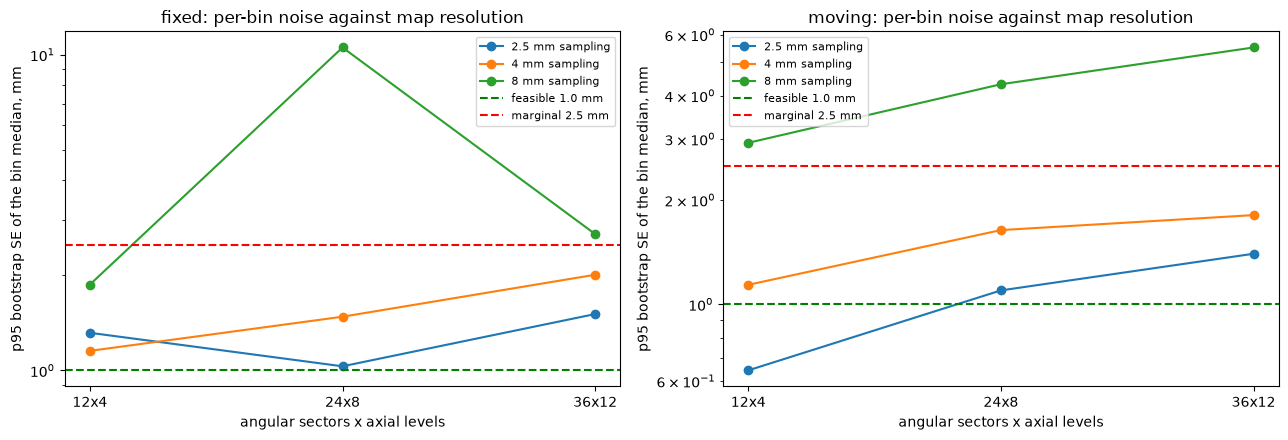

In [3]:
thresholds = summary["thresholds"]
phases = sorted(scan["phase"].unique())
resolutions = list(dict.fromkeys(scan["resolution"]))
densities = sorted(scan["sampling_density_mm"].unique())

fig, axes = plt.subplots(1, len(phases), figsize=(6.5 * len(phases), 4.5), squeeze=False)
for column, phase in enumerate(phases):
    axis = axes[0][column]
    subset = scan[scan["phase"] == phase]
    for density in densities:
        rows = subset[subset["sampling_density_mm"] == density]
        rows = rows.set_index("resolution").reindex(resolutions)
        axis.plot(
            resolutions,
            rows["p95_bootstrap_se_mm"],
            marker="o",
            label=f"{density:g} mm sampling",
        )
    axis.axhline(thresholds["feasible_max_mm"], color="green", ls="--", label="feasible 1.0 mm")
    axis.axhline(thresholds["marginal_max_mm"], color="red", ls="--", label="marginal 2.5 mm")
    axis.set_title(f"{phase}: per-bin noise against map resolution")
    axis.set_xlabel("angular sectors x axial levels")
    axis.set_ylabel("p95 bootstrap SE of the bin median, mm")
    axis.set_yscale("log")
    axis.legend(fontsize=8)
fig.tight_layout()

## Карта `h` по поверхности тела

Развёртка цилиндра: по горизонтали — угол вокруг оси тела, по вертикали — осевой уровень. `0` соответствует переднему направлению, `0.25` — правой стороне, `0.5` — задней, `0.75` — левой. Это распределение самой толщины мягких тканей, не её изменения.

NO SELECTION under the frozen rule; showing the lowest worst-phase
configuration for diagnosis only: worst-phase p95 1.096 mm
showing density 2.5 mm, resolution 24x8


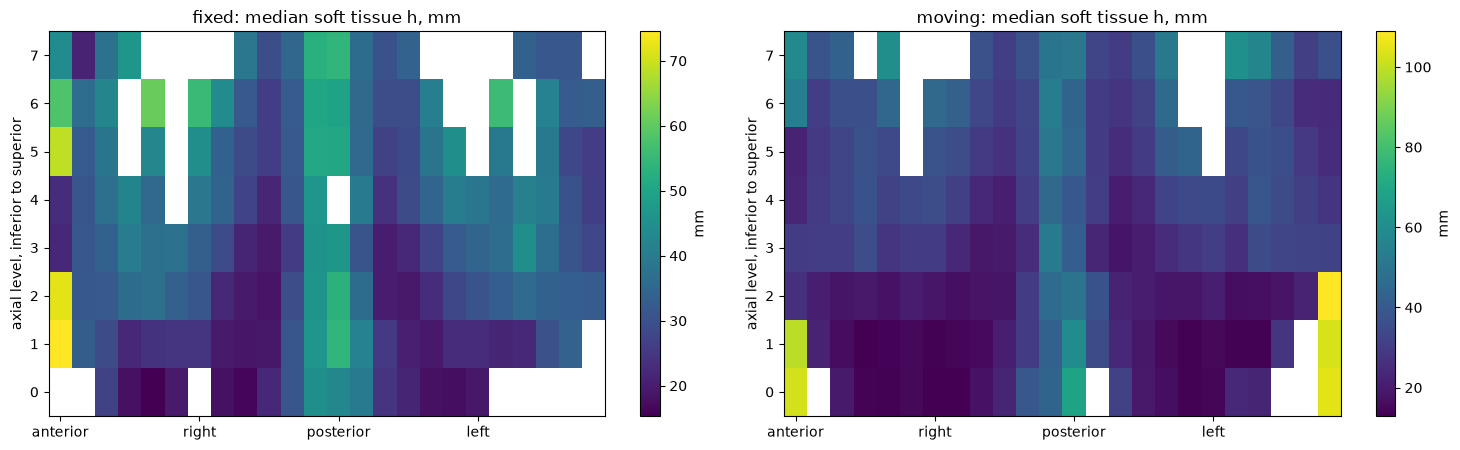

In [4]:
chosen_resolution = verdict["selected_resolution"]
chosen_density = verdict["selected_density_mm"]
if chosen_resolution is None:
    # No selection was made, so the display falls back to the configuration
    # with the lowest WORST-PHASE noise. This is a diagnostic view only: it is
    # not the frozen rule and it does not make the map reportable.
    worst = scan.groupby(["sampling_density_mm", "resolution"])[
        "p95_bootstrap_se_mm"
    ].max()
    chosen_density, chosen_resolution = worst.idxmin()
    print("NO SELECTION under the frozen rule; showing the lowest worst-phase")
    print(f"configuration for diagnosis only: worst-phase p95 {worst.min():.3f} mm")
print(f"showing density {chosen_density:g} mm, resolution {chosen_resolution}")

sectors, levels = (int(part) for part in str(chosen_resolution).split("x"))
selected = bins[
    (bins["resolution"] == chosen_resolution)
    & (bins["sampling_density_mm"] == chosen_density)
]


def grid(frame: pd.DataFrame, column: str) -> np.ndarray:
    values = np.full((levels, sectors), np.nan)
    values[frame["axial_level"], frame["angular_sector"]] = frame[column]
    return values


ticks = np.linspace(0, sectors, 5)[:-1]
labels = ["anterior", "right", "posterior", "left"]

fig, axes = plt.subplots(1, len(phases), figsize=(7.5 * len(phases), 4.6), squeeze=False)
for column, phase in enumerate(phases):
    axis = axes[0][column]
    values = grid(selected[selected["phase"] == phase], "median_mm")
    image = axis.imshow(values, origin="lower", aspect="auto", cmap="viridis")
    axis.set_xticks(ticks, labels)
    axis.set_ylabel("axial level, inferior to superior")
    axis.set_title(f"{phase}: median soft tissue h, mm")
    fig.colorbar(image, ax=axis, label="mm")
fig.tight_layout()

## Где карте можно верить

Тот же разрез, но показан шум на бин. Зона с высоким шумом не годится для вывода о размещении электродов независимо от того, насколько красиво выглядит соседняя карта толщины.

fixed: 154/163 occupied bins at or below 1.0 mm, median bin count 194
moving: 164/176 occupied bins at or below 1.0 mm, median bin count 245


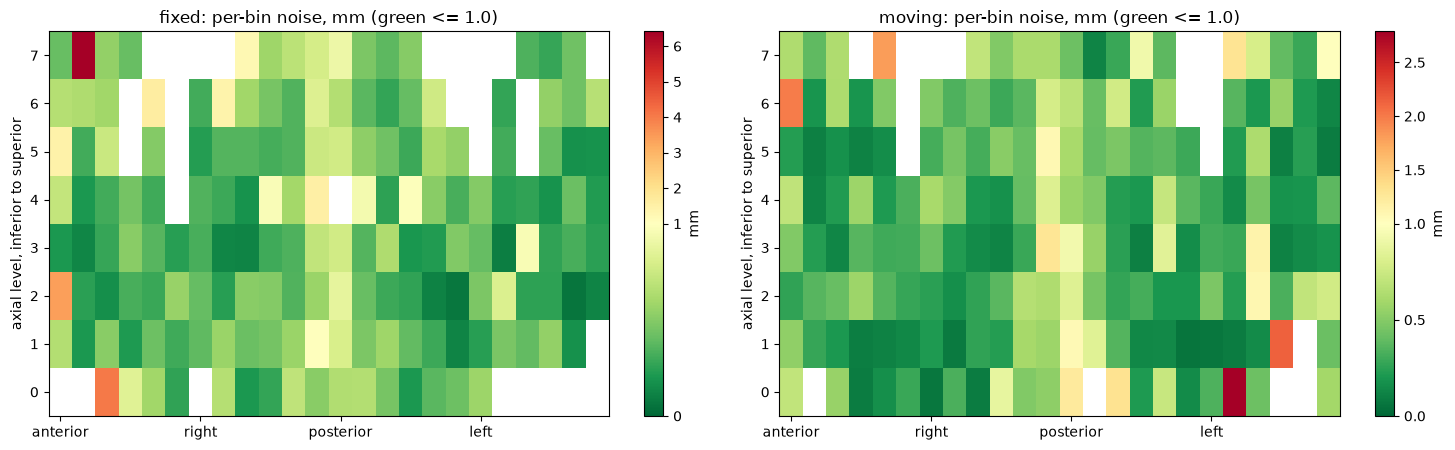

In [5]:
fig, axes = plt.subplots(1, len(phases), figsize=(7.5 * len(phases), 4.6), squeeze=False)
limit = float(thresholds["marginal_max_mm"])
for column, phase in enumerate(phases):
    axis = axes[0][column]
    values = grid(selected[selected["phase"] == phase], "bootstrap_se_mm")
    norm = TwoSlopeNorm(
        vmin=0.0, vcenter=float(thresholds["feasible_max_mm"]), vmax=max(limit, np.nanmax(values))
    )
    image = axis.imshow(values, origin="lower", aspect="auto", cmap="RdYlGn_r", norm=norm)
    axis.set_xticks(ticks, labels)
    axis.set_ylabel("axial level, inferior to superior")
    axis.set_title(f"{phase}: per-bin noise, mm (green <= 1.0)")
    fig.colorbar(image, ax=axis, label="mm")
fig.tight_layout()

for phase in phases:
    frame = selected[selected["phase"] == phase]
    good = int((frame["bootstrap_se_mm"] <= thresholds["feasible_max_mm"]).sum())
    print(
        f"{phase}: {good}/{len(frame)} occupied bins at or below "
        f"{thresholds['feasible_max_mm']} mm, median bin count "
        f"{frame['count'].median():.0f}"
    )

## Почему медиана по субъекту не годится

Разброс медиан между зонами на порядок больше эффекта, который ищется внутри зоны. Одно число по субъекту усредняет ровно ту информацию, ради которой строится карта.

In [6]:
for phase in phases:
    frame = selected[selected["phase"] == phase]
    spread = frame["median_mm"].max() - frame["median_mm"].min()
    print(
        f"{phase}: bin medians span {frame['median_mm'].min():.1f} to "
        f"{frame['median_mm'].max():.1f} mm, spread {spread:.1f} mm, "
        f"against a {thresholds['target_resolvable_effect_mm']:g} mm planning anchor"
    )

fixed: bin medians span 15.3 to 74.5 mm, spread 59.2 mm, against a 3 mm planning anchor
moving: bin medians span 12.9 to 108.9 mm, spread 96.0 mm, against a 3 mm planning anchor


## Заранее заданное решение

In [7]:
print(f"selection made:     {verdict['selection_made']}")
print(f"selected density:   {verdict['selected_density_mm']}")
print(f"selected resolution:{verdict['selected_resolution']}")
print(f"noise at selection: {verdict['selected_p95_noise_mm']}")
print(f"best noise in scan: {verdict['best_p95_noise_mm']:.4f} mm")
print()
for note in verdict["notes"]:
    print("-", note)
print("\nW2 compared no phases; the delta map stays blocked until Gate 1B.")

selection made:     False
selected density:   None
selected resolution:None
noise at selection: None
best noise in scan: 0.6440 mm

- W2 measures within-phase spatial stability; it compares no phases and produces no delta map.
- The per-bin noise is the bootstrap standard error of the bin median, the term that dominated the W1 spatial spread.
- A bin below the frozen minimum count is unresolved and is not plotted.
- No configuration met both the noise and the occupancy rule, so no resolution is selected and the map stays unreported.

W2 compared no phases; the delta map stays blocked until Gate 1B.
